# Executive Case Study — Power Portfolio Commercial Operations

This notebook gives an executive walkthrough of the synthetic portfolio, the business questions, KPI design, and key findings. **All data is fictional.**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
fact = pd.read_csv(ROOT/'data/raw/hourly_operations.csv', parse_dates=['timestamp'])
assets = pd.read_csv(ROOT/'data/raw/assets.csv')


## Portfolio scorecard

In [2]:
scorecard = pd.Series({
    'Generation (MWh)': fact.generation_mwh.sum(),
    'Market Revenue ($)': fact.market_revenue_usd.sum(),
    'Gross Margin ($)': fact.gross_margin_usd.sum(),
    'Margin / MWh ($)': fact.gross_margin_usd.sum()/fact.generation_mwh.sum(),
    'Availability': fact.available_flag.mean(),
    'Estimated Incremental Margin ($)': fact.estimated_incremental_margin_usd.sum()
})
scorecard

Generation (MWh)                    4.395837e+06
Market Revenue ($)                  1.593533e+08
Gross Margin ($)                    6.879808e+07
Margin / MWh ($)                    1.565073e+01
Availability                        9.856987e-01
Estimated Incremental Margin ($)    2.314779e+06
dtype: float64

## Asset contribution to gross margin

In [3]:
asset = fact.groupby(['asset_name','technology'], as_index=False).agg(generation_mwh=('generation_mwh','sum'), gross_margin_usd=('gross_margin_usd','sum'), availability=('available_flag','mean')).sort_values('gross_margin_usd', ascending=False)
asset

,asset_name,technology,generation_mwh,gross_margin_usd,availability
6,Riverbend CCGT,CCGT,1.776208e+06,1.764081e+07,0.973297
1,Highland Wind,Wind,5.007200e+05,1.548148e+07,0.998849
5,Prairie Wind,Wind,3.979819e+05,1.228437e+07,0.998849
4,Pine Ridge CCGT,CCGT,1.309744e+06,1.204742e+07,0.967541
7,Sunfield Solar,Solar,1.829904e+05,6.259400e+06,0.999309
3,Oak Valley Solar,Solar,1.297222e+05,4.196260e+06,0.999079
2,Magnolia CT,CT,5.260378e+04,4.702004e+05,0.978821
0,Cedar CT,CT,4.586736e+04,4.181505e+05,0.969843


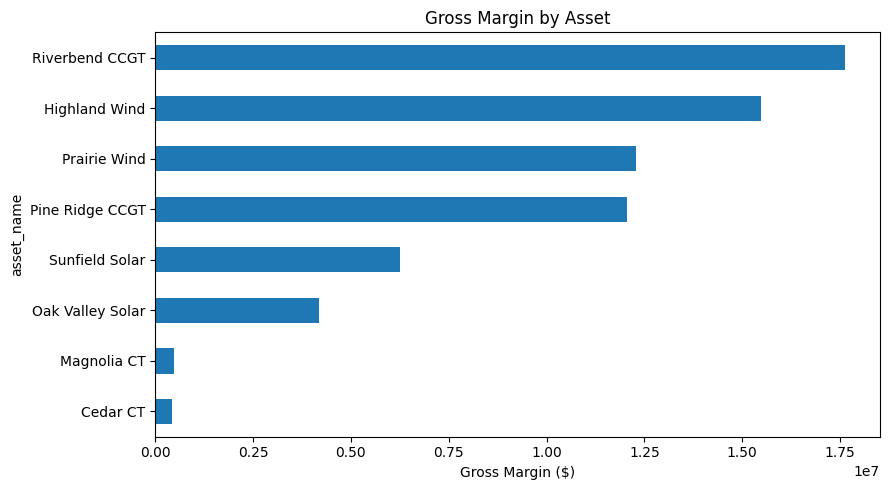

In [4]:
asset.sort_values('gross_margin_usd').plot.barh(x='asset_name', y='gross_margin_usd', figsize=(9,5), legend=False, title='Gross Margin by Asset')
plt.xlabel('Gross Margin ($)'); plt.tight_layout(); plt.show()

## Management interpretation

The portfolio view is designed to answer *what changed*, *where it changed*, and *what should be investigated next*. It combines operating KPIs with unit economics rather than treating generation and margin as separate reporting streams.

## Important limitation

The opportunity-screening metric is a simplified analytical flag. A production dispatch model would require unit constraints, start costs, contractual positions, transmission constraints, settlements, and market rules.